In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

df = pd.read_csv("../data/diabetes_data/diabetic_data.csv")
df = df.replace('?', np.nan)
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'])
df['race'] = df['race'].fillna('Unknown')

df = df.sort_values('encounter_id')
df = df.drop_duplicates(subset='patient_nbr', keep='first')

exclude_ids = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(exclude_ids)]

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

categorical_features = [
    'race', 'gender', 'age', 'admission_type_id',
    'discharge_disposition_id', 'admission_source_id',
    'A1Cresult', 'max_glu_serum', 'change', 'diabetesMed', 'insulin'
]

X = df[numeric_features + categorical_features]
y = df['readmitted_binary']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((55978, 76), (13995, 76))

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = HistGradientBoostingClassifier(max_depth=6, class_weight='balanced', random_state=42)
gb_model.fit(X_train, y_train)

,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form `{class_label: weight}`.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas `n_samples / (n_classes * np.bincount(y))`.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if `sample_weight` is specified... versionadded:: 1.2",'balanced'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


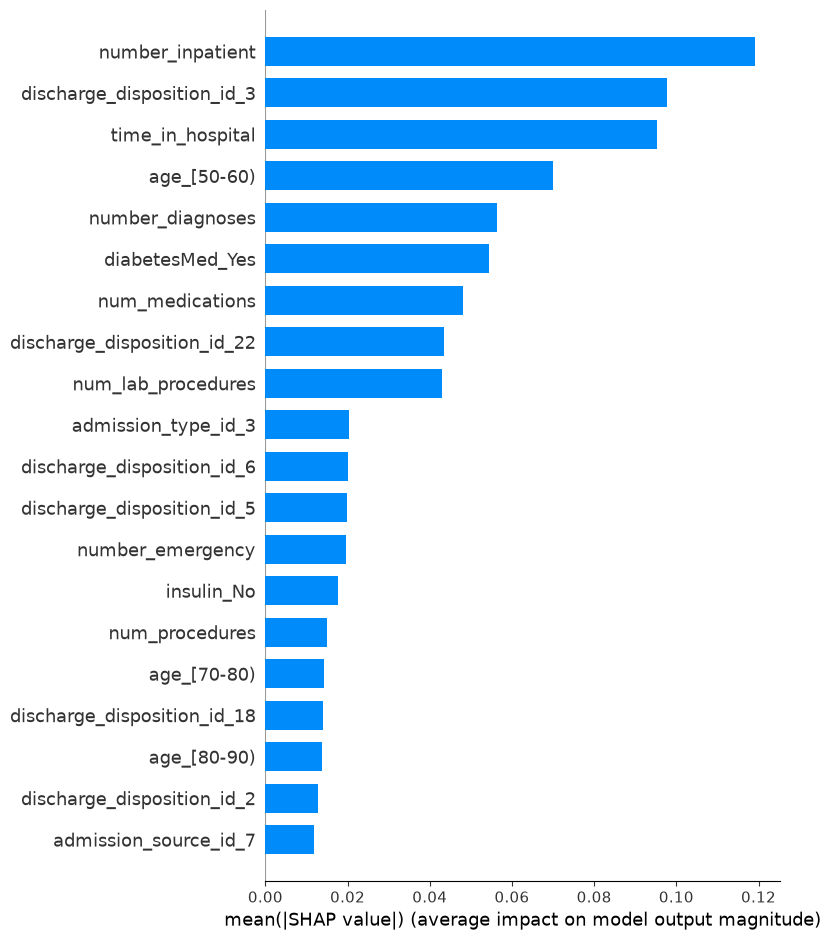

In [9]:
import shap

explainer = shap.TreeExplainer(gb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar')

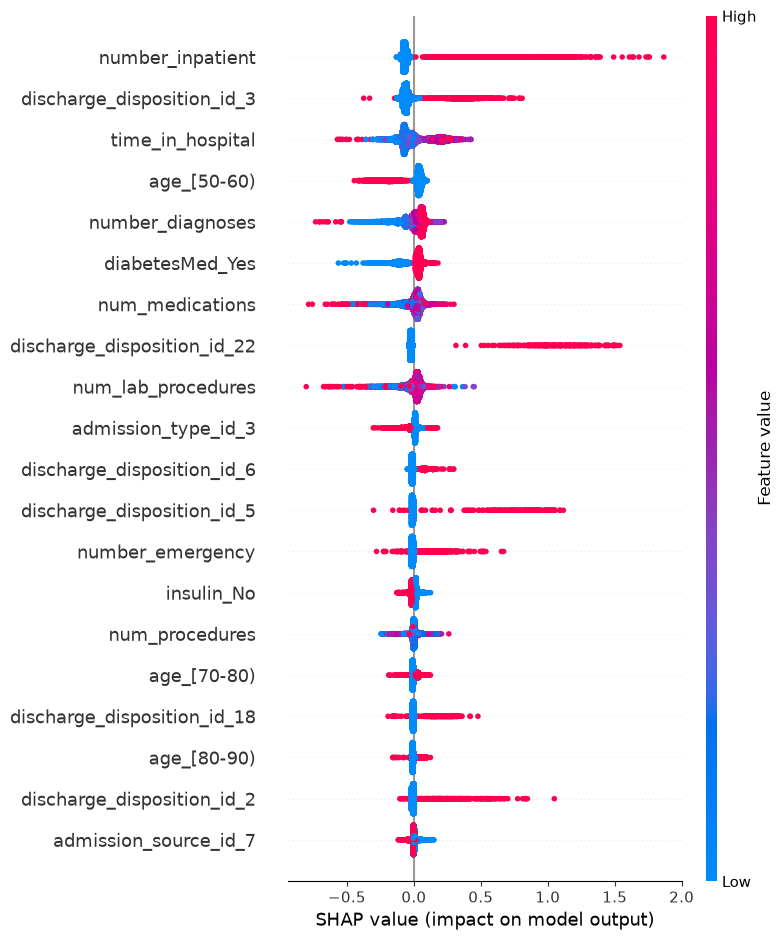

In [10]:
shap.summary_plot(shap_values, X_test)

The model's top drivers are number_inpatient (prior hospitalizations), and discharge destination (skilled nursing facility or rehab vs. home) — both of which align with real clinical intuition: patients with a history of frequent hospitalization, or who are discharged somewhere other than home, are predicted at meaningfully higher risk. One less intuitive finding: being in the 50–60 age bracket specifically was associated with slightly lower predicted risk relative to other age groups, worth further investigation rather than an obvious story.